In [1]:
import pandas as pd
import numpy as np

# NLP
import re
import string

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("librarians-by-msa.csv")

# View data
df.head()

,prim_state,area_name,tot_emp,emp_prse,jobs_1000,loc_quotient
0,OH,"Springfield, OH",**,**,**,**
1,WA,"Mount Vernon-Anacortes, WA",**,**,**,**
2,PR,"Aguadilla-Isabela-San Sebastian, PR",160,4.4,3.727,3.62
3,PR,"Ponce, PR",180,3.6,3.434,3.34
4,PR,"San German-Cabo Rojo, PR",50,0.2,2.679,2.6


In [3]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   prim_state    373 non-null    str  
 1   area_name     373 non-null    str  
 2   tot_emp       373 non-null    str  
 3   emp_prse      373 non-null    str  
 4   jobs_1000     373 non-null    str  
 5   loc_quotient  373 non-null    str  
dtypes: str(6)
memory usage: 31.3 KB


Index(['prim_state', 'area_name', 'tot_emp', 'emp_prse', 'jobs_1000',
       'loc_quotient'],
      dtype='str')

In [4]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [6]:
print(df.columns)

Index(['prim_state', 'area_name', 'tot_emp', 'emp_prse', 'jobs_1000',
       'loc_quotient'],
      dtype='str')


In [7]:
for col in df.columns:
    print(repr(col))

'prim_state'
'area_name'
'tot_emp'
'emp_prse'
'jobs_1000'
'loc_quotient'


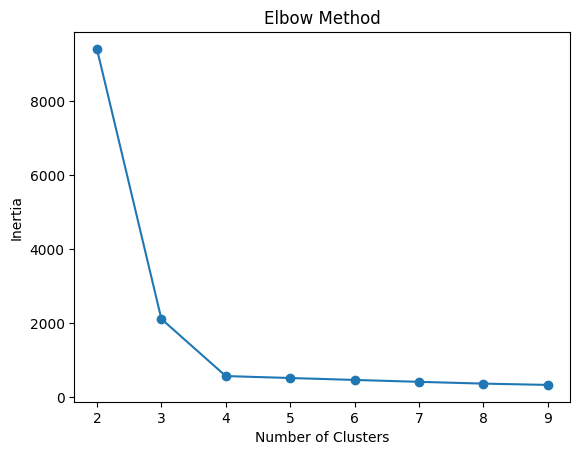

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# sample data (replace this with your real data)
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [11]:
[c for c in df.columns if 'cluster' in c.lower()]

[]

In [17]:
documents = [
    "cats are great pets",
    "dogs are loyal animals",
    "cats and dogs can live together",
    "I love machine learning",
    "KMeans clustering is useful for text"
]

In [19]:
print(df.head())
print(df.columns)

  prim_state                            area_name tot_emp emp_prse jobs_1000  \
0         OH                      Springfield, OH      **       **        **   
1         WA           Mount Vernon-Anacortes, WA      **       **        **   
2         PR  Aguadilla-Isabela-San Sebastian, PR     160      4.4     3.727   
3         PR                            Ponce, PR     180      3.6     3.434   
4         PR             San German-Cabo Rojo, PR      50      0.2     2.679   

  loc_quotient  
0           **  
1           **  
2         3.62  
3         3.34  
4          2.6  
Index(['prim_state', 'area_name', 'tot_emp', 'emp_prse', 'jobs_1000',
       'loc_quotient'],
      dtype='str')


In [21]:
print(df.columns.tolist())

['prim_state', 'area_name', 'tot_emp', 'emp_prse', 'jobs_1000', 'loc_quotient']
